
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/tunnel-ai/way/blob/main/notebooks/02_00_main.ipynb)

In [15]:
# --- Course setup (un comment in run if using colab) ---
#!git clone https://github.com/tunnel-ai/way.git
#import sys; sys.path.insert(0, "/content/way/src")


# Module 2 — Supervised Learning: Regression 

**When regression goes wrong**: This workbook highlights some typical issues related to regression problems. 
**Target:** `transaction_loss_amount` (continuous, zero-inflated; heavy right tail for fraud cases)  
**dataset:** Same as the prior one. `core.generators.transaction_risk_dgp.generate_transaction_risk_dataset(seed=1955)`  

**How to run (Colab):**
1. Open notebook from GitHub with the **Open in Colab** button. 
2. Run the first cell (it clones the repo and sets `sys.path`). It might be commented out, if so uncomment. The rest of the workbooks in mod 1-4 use the same generator.


In [16]:
# --- Imports ------------------------------------------------------------------
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.compose import TransformedTargetRegressor

RANDOM_STATE = 1955
np.random.seed(RANDOM_STATE)



In [17]:
# --- Load canonical dataset (don't modify generator) --------------------------
from core.generators.transaction_risk_dgp import generate_transaction_risk_dataset

df = generate_transaction_risk_dataset(seed=RANDOM_STATE)

print(df.shape)
df.head()


(126521, 24)


,transaction_id,account_id,merchant_id,merchant_name,merchant_category,payment_channel,country,is_foreign_transaction,device_type,is_new_device,...,transactions_last_7d,transaction_amount,avg_transaction_amount_30d,std_transaction_amount_30d,merchant_description,is_fraud,transaction_loss_amount,chargeback_flag,manual_review_score,fraud_probability_latent
0,1,1,3082,MERCH_3082,education,online,US,0,NaN,0,...,46,4.69,12.25,9.82,MERCH_3082 education ONLINE -X,0,0.0,0,0.331,0.0181
1,2,1,3,WALMART,charity,card_present,US,0,NaN,0,...,44,14.54,7.56,11.20,NaN,0,0.0,0,0.000,0.0071
2,3,1,1,AMAZON,rideshare,card_present,US,0,pos_terminal,0,...,39,12.64,11.76,5.07,AMAZON rideshare POS CO,0,0.0,0,0.000,0.0217
3,4,1,12,TARGET,utilities,online,US,0,mobile_web,0,...,37,8.41,9.74,17.60,TARGET utilities ONLINE -X,0,0.0,0,0.103,0.0058
4,5,1,51,MERCH_0051,utilities,mobile,US,0,mobile_app,0,...,59,9.84,8.41,4.40,MERCH_0051 utilities MOB PAY,0,0.0,0,0.101,0.0015


## 1) Problem framing: why regression is tricky here

`transaction_loss_amount` is **zero** for non-fraud transactions and **positive / heavy-tailed** for fraud transactions. So we have **zero-inflated, right-skewed** target distribution.

It's a common occurrence in practice (e.g., claims, chargebacks, returns): many zeros, a few large outcomes.


Rows: 126,521
Zero rate in transaction_loss_amount: 94.8%
Target quantiles (including zeros):


0.000     0.0000
0.500     0.0000
0.900     0.0000
0.950     0.7800
0.990    14.6900
0.995    23.0900
0.999    66.2396
Name: transaction_loss_amount, dtype: float64

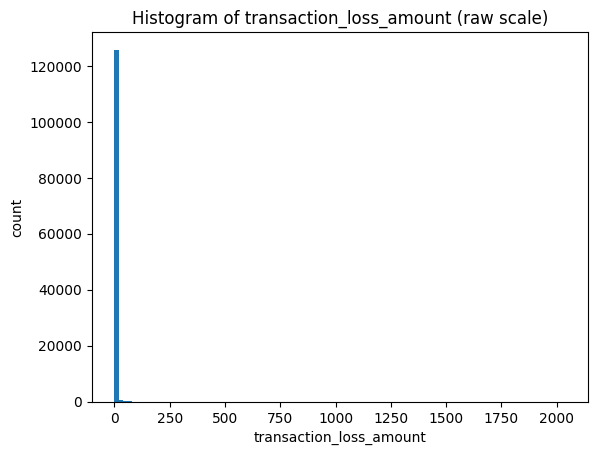

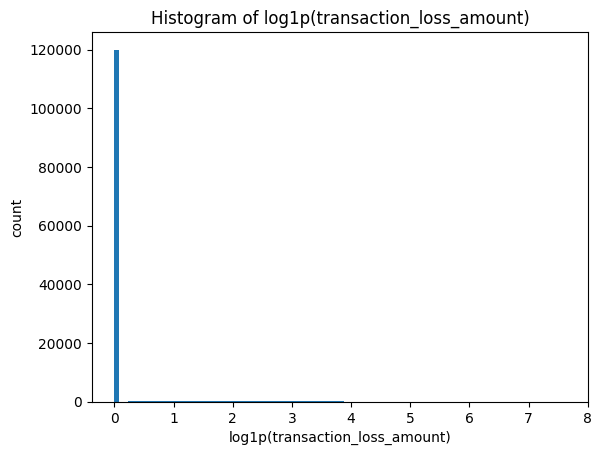

In [18]:
# --- Target distribution: zeros + heavy tail ----------------------------------
TARGET = "transaction_loss_amount"

y = df[TARGET]
zero_rate = (y == 0).mean()

print(f"Rows: {len(df):,}")
print(f"Zero rate in {TARGET}: {zero_rate:.1%}")
print("Target quantiles (including zeros):")
display(y.quantile([0, .5, .9, .95, .99, .995, .999]))

fig, ax = plt.subplots()
ax.hist(y, bins=100)
ax.set_title(f"Histogram of {TARGET} (raw scale)")
ax.set_xlabel(TARGET)
ax.set_ylabel("count")
plt.show()

fig, ax = plt.subplots()
ax.hist(np.log1p(y), bins=100)
ax.set_title(f"Histogram of log1p({TARGET})")
ax.set_xlabel(f"log1p({TARGET})")
ax.set_ylabel("count")
plt.show()


## 2) Train/test split + feature audit

We're going to build a fairly minimal (time!) **baseline pipeline** to manage:
- numeric features with missing values (impute + optional scaling)
- categorical features with missing values (impute + one-hot encoding)
- **high-cardinality** `merchant_id` (...carefully)

We will not “clean” the dataset outside pipelines, the preprocessing stays inside the model pipeline to avoid leakage.

(as a reminder... in a production workflow you'd wrap all this up... we are walking it step by step)


In [19]:
# --- Define features / targets ------------------------------------------------
# Mirror Module 1's leakage hygiene — the regression target is loss in $, but the dataset
# also carries fraud labels and post-outcome signals that would let any model "cheat."
LEAKAGE_COLS = [
    "is_fraud",                  # classification label; loss > 0 only when fraud=1
    "chargeback_flag",            # post-event outcome
    "manual_review_score",        # post-event review
    "fraud_probability_latent",   # the latent generator probability — pure leakage
]
ID_COLS = ["transaction_id", "account_id"]  # pure identifiers, no predictive value

X = df.drop(columns=[TARGET] + LEAKAGE_COLS + ID_COLS).copy()

# Treat merchant_id as a high-cardinality CATEGORY, not a continuous integer.
# Without this cast, merchant_id (int64) silently slips into the numeric pipeline
# and gets a single coefficient — meaningless when the ID is arbitrary.
X["merchant_id"] = X["merchant_id"].astype(str)

y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE
)

# Identify column types
categorical_cols = X_train.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
numeric_cols = [c for c in X_train.columns if c not in categorical_cols]

print("n_train:", X_train.shape, "n_test:", X_test.shape)
print("Categorical:", categorical_cols)
print("Numeric (first 15):", numeric_cols[:15])

# Quick missingness + cardinality audit
miss = X_train.isna().mean().sort_values(ascending=False)
card = {c: X_train[c].nunique(dropna=True) for c in categorical_cols}
card_s = pd.Series(card).sort_values(ascending=False)

display(pd.DataFrame({"missing_rate": miss}).head(10))
display(pd.DataFrame({"n_unique": card_s}))

n_train: (94890, 17) n_test: (31631, 17)
Categorical: ['merchant_id', 'merchant_name', 'merchant_category', 'payment_channel', 'country', 'device_type', 'merchant_description']
Numeric (first 15): ['is_foreign_transaction', 'is_new_device', 'is_high_risk_merchant', 'hour_of_day', 'time_since_last_transaction_minutes', 'transactions_last_24h', 'transactions_last_7d', 'transaction_amount', 'avg_transaction_amount_30d', 'std_transaction_amount_30d']


,missing_rate
device_type,0.666519
merchant_description,0.101718
merchant_category,0.094826
time_since_last_transaction_minutes,0.000000
std_transaction_amount_30d,0.000000
avg_transaction_amount_30d,0.000000
transaction_amount,0.000000
transactions_last_7d,0.000000
transactions_last_24h,0.000000
merchant_id,0.000000


,n_unique
merchant_description,24960
merchant_id,4525
merchant_name,4525
merchant_category,18
country,10
payment_channel,5
device_type,5


## 3) Baselines: “predict the mean” and “predict zero”

Two baselines:

1) **Mean baseline**: always predict the mean of the training target. Often surprisingly useful. Maybe not here. 
2) **Zero baseline**: always predict 0 (often really strong when there are many zeros)

If a model *can’t* beat these, it’s not learning a useful signal.


In [20]:
def regression_report(y_true, y_pred, label="model"):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    r2 = r2_score(y_true, y_pred)
    return pd.Series({"MAE": mae, "RMSE": rmse, "R2": r2}, name=label)

mean_pred = np.full_like(y_test, fill_value=float(y_train.mean()), dtype=float)
zero_pred = np.zeros_like(y_test, dtype=float)

# Accumulate per-model results in a list of Series; concat all at once for display.
# This avoids the broken cumulative axis=0 concat pattern.
all_results = []
all_results.append(regression_report(y_test, mean_pred, "Baseline: mean(y_train)"))
all_results.append(regression_report(y_test, zero_pred, "Baseline: always 0"))

pd.concat(all_results, axis=1).T

,MAE,RMSE,R2
Baseline: mean(y_train),1.303700,8.703338,-0.000013
Baseline: always 0,0.672069,8.729194,-0.005963


## 4) Linear regression with a real preprocessing pipeline

Fit an **OLS linear regression** on a feature matrix that mixes:
- numeric variables (e.g., `transaction_amount`, `account_age_days`, risk counts)
- categorical variables (e.g., `channel`, `merchant_category`, `merchant_id`)

Key design choice/warning: how to encode high-cardinality categories like `merchant_id`?

We’ll start with OneHotEncoder using **frequency-based grouping** (not available in all sklearn versions... looking at you colab...).  

If not available, we’ll fall back to plain one-hot with `handle_unknown='ignore'`.


In [21]:
# --- Preprocessing ------------------------------------------------------------
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        # Scaling isn't strictly required for OLS, but helps when we move to regularization.
        ("scaler", StandardScaler(with_mean=False)),
    ]
)

# OneHotEncoder behavior can vary slightly by sklearn version! (root of all Python ills...)
# We'll try to enable frequency-based grouping to reduce merchant_id explosion.
def make_ohe():
    try:
        return OneHotEncoder(handle_unknown="ignore", min_frequency=50)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore")

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", make_ohe()),
    ]
)

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols),
    ],
    remainder="drop",
    sparse_threshold=0.3,
)

ols_model = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", LinearRegression()),
    ]
)

ols_model


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

In [22]:
# --- Fit + evaluate -----------------------------------------------------------
ols_model.fit(X_train, y_train)

y_pred = ols_model.predict(X_test)

all_results.append(regression_report(y_test, y_pred, "OLS + one-hot"))

pd.concat(all_results, axis=1).T

,MAE,RMSE,R2
Baseline: mean(y_train),1.303700,8.703338,-0.000013
Baseline: always 0,0.672069,8.729194,-0.005963
OLS + one-hot,1.481910,8.842516,-0.032251


### Watch the zero baseline

Look at **MAE** in the table above: the "always predict 0" baseline is hard to beat — and a vanilla OLS may actually have *higher* MAE than just predicting zero everywhere.

This is the zero-inflation gotcha. OLS minimizes squared error (MSE), which is dominated by the heavy fraud tail. To reduce those big squared errors, the model pulls its predictions slightly above zero across all transactions — even the ~95% with true loss of zero. Those small positive predictions translate into small absolute errors that add up to a higher MAE than the trivial "always 0" rule.

What OLS *does* improve is **RMSE** (sensitive to the tail) and **R²** (variance explained). On those metrics, the model beats the baseline.

**Lesson:** under heavy zero-inflation, MAE and RMSE can disagree about which model is "best." The choice of metric is part of the modeling problem — pick the one that matches the cost structure you actually care about. (And: always benchmark against the dumbest baseline. Sometimes it wins.)

### Diagnostics: prediction scatter + residuals

A linear model can be “good enough” on average while failing badly in the tail.  
Because loss is heavy-tailed, look at:
- predicted vs actual
- residuals vs predicted
- residual histogram (often skewed / heteroskedastic)


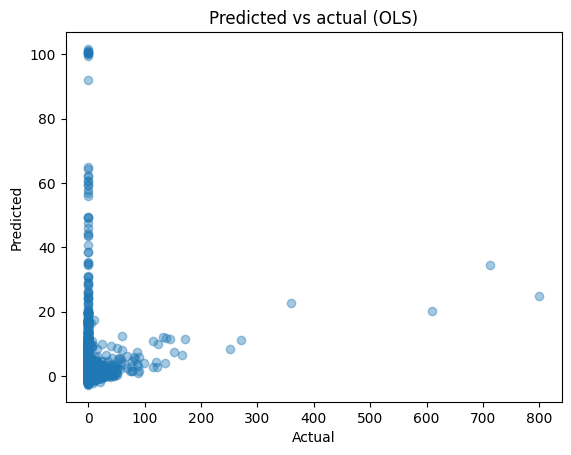

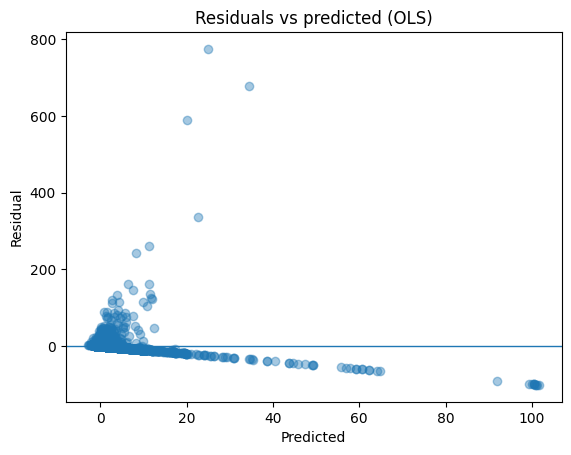

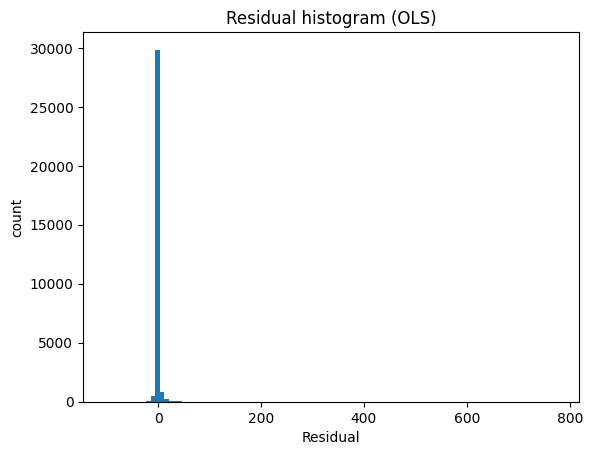

In [23]:
resid = y_test - y_pred

fig, ax = plt.subplots()
ax.scatter(y_test, y_pred, alpha=0.4)
ax.set_title("Predicted vs actual (OLS)")
ax.set_xlabel("Actual")
ax.set_ylabel("Predicted")
plt.show()

fig, ax = plt.subplots()
ax.scatter(y_pred, resid, alpha=0.4)
ax.axhline(0, linewidth=1)
ax.set_title("Residuals vs predicted (OLS)")
ax.set_xlabel("Predicted")
ax.set_ylabel("Residual")
plt.show()

fig, ax = plt.subplots()
ax.hist(resid, bins=100)
ax.set_title("Residual histogram (OLS)")
ax.set_xlabel("Residual")
ax.set_ylabel("count")
plt.show()


## 5) A pragmatic fix: model the log-loss

When targets are right-skewed, a common baseline improvement is to model:

\[
\log(1 + \text{loss})
\]

Then transform predictions back. This often improves RMSE and makes residuals behave better, but:
- it changes the loss function implicitly
- it can under-predict the extreme tail

We’ll use `TransformedTargetRegressor` so the transform is handled safely.


In [24]:
log_ols = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", TransformedTargetRegressor(
            regressor=LinearRegression(),
            func=np.log1p,
            inverse_func=np.expm1
        )),
    ]
)

log_ols.fit(X_train, y_train)
y_pred_log = log_ols.predict(X_test)

all_results.append(regression_report(y_test, y_pred_log, "OLS on log1p(loss)"))

pd.concat(all_results, axis=1).T

,MAE,RMSE,R2
Baseline: mean(y_train),1.303700,8.703338,-0.000013
Baseline: always 0,0.672069,8.729194,-0.005963
OLS + one-hot,1.481910,8.842516,-0.032251
OLS on log1p(loss),0.772059,8.715984,-0.002921


## 6) Polynomial regression (carefully)

Polynomial terms can capture **nonlinearities** and **interactions** in a way that stays “linear in parameters.”  
But polynomial expansion with many features can explode the feature space.

So here we demonstrate polynomial regression on a **single predictor** (`transaction_amount`) as a controlled example.


In [25]:
# --- Polynomial regression demo: transaction_amount only ----------------------
# This is intentionally small + interpretable.
poly_X_train = X_train[["transaction_amount"]].copy()
poly_X_test  = X_test[["transaction_amount"]].copy()

poly_model = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("poly", PolynomialFeatures(degree=3, include_bias=False)),
        ("ridge", Ridge(alpha=1.0, random_state=RANDOM_STATE)),
    ]
)

poly_model.fit(poly_X_train, y_train)
poly_pred = poly_model.predict(poly_X_test)

all_results.append(regression_report(y_test, poly_pred, "Poly(deg=3) on transaction_amount"))

pd.concat(all_results, axis=1).T

,MAE,RMSE,R2
Baseline: mean(y_train),1.303700,8.703338,-0.000013
Baseline: always 0,0.672069,8.729194,-0.005963
OLS + one-hot,1.481910,8.842516,-0.032251
OLS on log1p(loss),0.772059,8.715984,-0.002921
Poly(deg=3) on transaction_amount,1.287566,8.826052,-0.028411


## 7) Regularization: Ridge / Lasso / Elastic Net

With many correlated predictors (and one-hot categories), OLS can be unstable.  
Regularization adds a penalty term that controls coefficient magnitude:

- **Ridge (L2)** shrinks coefficients smoothly (good with correlated features)
- **Lasso (L1)** can drive some coefficients to 0 (feature selection)
- **Elastic Net** mixes both

We’ll tune hyperparameters with cross-validation.


In [26]:
# --- Shared pipeline pieces ---------------------------------------------------
def make_reg_pipeline(regressor):
    return Pipeline(steps=[("preprocess", preprocess), ("model", regressor)])

param_grid = {
    "model__alpha": [0.01, 0.1, 1.0, 10.0, 100.0]
}

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Ridge
ridge_pipe = make_reg_pipeline(Ridge(random_state=RANDOM_STATE))
ridge_search = GridSearchCV(ridge_pipe, param_grid=param_grid, cv=cv, scoring="neg_root_mean_squared_error", n_jobs=-1)
ridge_search.fit(X_train, y_train)

# Lasso (may need more iterations)
lasso_pipe = make_reg_pipeline(Lasso(max_iter=20000, random_state=RANDOM_STATE))
lasso_search = GridSearchCV(lasso_pipe, param_grid=param_grid, cv=cv, scoring="neg_root_mean_squared_error", n_jobs=-1)
lasso_search.fit(X_train, y_train)

# Elastic Net
enet_pipe = make_reg_pipeline(ElasticNet(max_iter=20000, random_state=RANDOM_STATE))
enet_grid = {
    "model__alpha": [0.01, 0.1, 1.0, 10.0],
    "model__l1_ratio": [0.1, 0.5, 0.9],
}
enet_search = GridSearchCV(enet_pipe, param_grid=enet_grid, cv=cv, scoring="neg_root_mean_squared_error", n_jobs=-1)
enet_search.fit(X_train, y_train)

print("Best Ridge:", ridge_search.best_params_)
print("Best Lasso:", lasso_search.best_params_)
print("Best ElasticNet:", enet_search.best_params_)


Best Ridge: {'model__alpha': 100.0}
Best Lasso: {'model__alpha': 0.1}
Best ElasticNet: {'model__alpha': 0.1, 'model__l1_ratio': 0.1}


In [27]:
# --- Evaluate best regularized models on the test set -------------------------
ridge_best = ridge_search.best_estimator_
lasso_best = lasso_search.best_estimator_
enet_best  = enet_search.best_estimator_

ridge_pred = ridge_best.predict(X_test)
lasso_pred = lasso_best.predict(X_test)
enet_pred  = enet_best.predict(X_test)

all_results.append(regression_report(y_test, ridge_pred, "Ridge (CV-tuned)"))
all_results.append(regression_report(y_test, lasso_pred, "Lasso (CV-tuned)"))
all_results.append(regression_report(y_test, enet_pred, "ElasticNet (CV-tuned)"))

pd.concat(all_results, axis=1).T

,MAE,RMSE,R2
Baseline: mean(y_train),1.303700,8.703338,-0.000013
Baseline: always 0,0.672069,8.729194,-0.005963
OLS + one-hot,1.481910,8.842516,-0.032251
OLS on log1p(loss),0.772059,8.715984,-0.002921
Poly(deg=3) on transaction_amount,1.287566,8.826052,-0.028411
Ridge (CV-tuned),1.433690,8.820834,-0.027195
Lasso (CV-tuned),1.312238,8.779226,-0.017528
ElasticNet (CV-tuned),1.317725,8.753924,-0.011671


## 8) High-cardinality `merchant_id`: a concrete experiment

`merchant_id` is high-cardinality. One-hot encoding can:
- create a **HUGE** sparse matrix
- memorize merchant effects (sometimes helpful, sometimes leakage-ish depending on context)
- increase variance if many merchants appear rarely

A quick sanity check is to compare performance **with** and **without** `merchant_id`.


In [28]:
# --- Compare a model with and without merchant_id -----------------------------
X_train_no_mid = X_train.drop(columns=["merchant_id"], errors="ignore")
X_test_no_mid  = X_test.drop(columns=["merchant_id"], errors="ignore")

cat_no_mid = X_train_no_mid.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
num_no_mid = [c for c in X_train_no_mid.columns if c not in cat_no_mid]

preprocess_no_mid = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_no_mid),
        ("cat", Pipeline(steps=[("imputer", SimpleImputer(strategy="most_frequent")),
                               ("onehot", make_ohe())]), cat_no_mid),
    ],
    remainder="drop",
    sparse_threshold=0.3,
)

ridge_no_mid = Pipeline(steps=[("preprocess", preprocess_no_mid), ("model", Ridge(alpha=ridge_search.best_params_["model__alpha"], random_state=RANDOM_STATE))])
ridge_no_mid.fit(X_train_no_mid, y_train)
pred_no_mid = ridge_no_mid.predict(X_test_no_mid)

compare_mid = pd.concat(
    [
        regression_report(y_test, ridge_pred, "Ridge (with merchant_id)"),
        regression_report(y_test, pred_no_mid, "Ridge (without merchant_id)"),
    ],
    axis=1
).T

compare_mid


,MAE,RMSE,R2
Ridge (with merchant_id),1.433690,8.820834,-0.027195
Ridge (without merchant_id),1.425366,8.816033,-0.026077


## Some notes

- **Zero inflation matters**: always benchmark against “predict 0” as well as “predict the mean.”
- **Pipelines are useful... maybe even required?**: preprocessing belongs inside the model pipeline to avoid leakage.
- **The metric is a choice**: MAE vs RMSE tells you whether you care more about typical errors or tail errors.
- **Linear models are baselines**: they are fast, interpretable, and useful even when they are misspecified.
- **High-cardinality categories... have to make decisions**: one-hot (with grouping), hashing, target encoding, or dropping the feature.

## Check in-- how are we doing here? 
1. Load the dataset and articulate why the regression target is structurally challenging.
2. Build a preprocessing pipeline for mixed numeric/categorical data.
3. Evaluate regression models using MAE, RMSE, and R².
4. Use residual plots to diagnose common issues.
5. Explain how Ridge/Lasso/ElasticNet change model behavior relative to OLS.
